# Phase 3 — Modeling, Feature Engineering, and Domain Adaptation

**Project:** Heart Disease ML — AI in Medicine  
**Goal:** train three optimized models on Cleveland only while introducing the two main methodological contributions for this phase:

1. **Feature engineering** beyond the raw UCI attributes.
2. **Domain adaptation** as an isolated, ablatable module for Cleveland → Hungarian/Swiss transfer.

This notebook is a **runner/report**. It can train and display results inline, but it intentionally does **not save model checkpoints or output files**. Persistent outputs should be created by the future `src/03_modeling.py` implementation runner.

## Prompt

Think about the two-layer contribution: (1) feature engineering to go beyond the raw 14 attributes, and (2) domain adaptation to make the Cleveland → Hungarian/Swiss transfer a real methodological step.

Search for clinical interaction terms relevant to heart disease, such as `age × max heart rate` and `chest pain type × thal`, and the Framingham risk score formula as a derived feature. Also search for simple domain adaptation approaches on tabular data, such as feature normalization per-site or CORAL covariance alignment.

Plan: build a feature engineering module that adds interaction terms and the Framingham proxy, then fit the shared preprocessing pipeline — imputer + scaler — on Cleveland only. Keep domain adaptation isolated so it can be toggled on/off for Phase 4 ablation. Train Logistic Regression, XGBoost with Optuna, and a small MLP on engineered Cleveland features using 5-fold CV.

Check that EDA findings from Phase 2 are reflected. Features with high distribution shift should be explicitly handled or at least flagged.

Execute: train and tune all three models with 5-fold CV on Cleveland.

Evaluate: confirm each model uses engineered features, Optuna runs at least 50 trials for XGBoost, and the domain adaptation step is isolated in its own module so it can be ablated in Phase 4.

## Design notes

The Framingham Risk Score normally requires variables such as age, sex, cholesterol, systolic blood pressure, smoking, diabetes, HDL cholesterol, and blood-pressure medication status. The UCI dataset does not contain all of these. Therefore, this notebook creates a **Framingham-inspired proxy**, not the true clinical Framingham score. It uses available UCI variables: age, sex, cholesterol, resting blood pressure, and fasting blood sugar as a rough diabetes-like risk proxy.

CORAL is included as an isolated unsupervised domain adaptation transformer. It aligns second-order covariance statistics between source and target feature spaces. In Phase 3, it is implemented and smoke-tested, but final external evaluation and ablation belong to Phase 4.

In [20]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
N_SPLITS = 5
XGB_OPTUNA_TRIALS = 50

In [21]:
# Optional dependencies are checked explicitly so the notebook fails with a useful message.
try:
    import optuna
except ImportError as exc:
    raise ImportError("Optuna is required for Phase 3. Install it with: pip install optuna") from exc

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError("XGBoost is required for Phase 3. Install it with: pip install xgboost") from exc

## Check — Load Phase 1 data

In [22]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PHASE1_PATH = PROJECT_ROOT / "src" / "01_dataset.py"
assert PHASE1_PATH.exists(), f"Cannot find Phase 1 runner at: {PHASE1_PATH}"

spec = importlib.util.spec_from_file_location("phase1_dataset", PHASE1_PATH)
phase1_dataset = importlib.util.module_from_spec(spec)
spec.loader.exec_module(phase1_dataset)

phase1_outputs = phase1_dataset.run_dataset_setup()

cleveland = phase1_outputs["cleveland"].copy()
hungarian = phase1_outputs["hungarian"].copy()
swiss = phase1_outputs["swiss"].copy()

print("Loaded splits:")
for name, df in {"cleveland": cleveland, "hungarian": hungarian, "swiss": swiss}.items():
    print(f"{name:10s}: shape={df.shape}, positive_rate={df['target'].mean():.2%}")


Phase 1 — Dataset setup
Loading Cleveland, Hungarian, and Swiss UCI Heart Disease splits...
Found local file for cleveland: /Users/aexomir/Desktop/AIMed/data/raw/processed.cleveland.data
Found local file for hungarian: /Users/aexomir/Desktop/AIMed/data/raw/processed.hungarian.data
Found local file for swiss: /Users/aexomir/Desktop/AIMed/data/raw/processed.switzerland.data
Column alignment check passed for Cleveland, Hungarian, and Swiss.

CLEVELAND
Shape: 303 rows × 16 columns

Binary label distribution:
target
0    164
1    139
Positive disease rate: 45.87%

Original target values before binary collapse:
target_original
0    164
1     55
2     36
3     35
4     13

Missing values in modeling columns:
ca      4
thal    2

HUNGARIAN
Shape: 294 rows × 16 columns

Binary label distribution:
target
0    188
1    106
Positive disease rate: 36.05%

Original target values before binary collapse:
target_original
0    188
1    106

Missing values in modeling columns:
trestbps      1
chol      

## Check — Load Phase 2 EDA outputs

This notebook expects the Phase 2 EDA runner to save exactly these files under `outputs/tables/`:

- `class_balance.csv`
- `distribution_shift_summary.csv`
- `missingness_summary.csv`

The notebook does not search through candidate names. If one is missing, it reports it clearly and continues.

In [23]:
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
EDA_TABLE_PATHS = {
    "class_balance": TABLE_DIR / "class_balance.csv",
    "distribution_shift": TABLE_DIR / "distribution_shift_summary.csv",
    "missingness": TABLE_DIR / "missingness_summary.csv",
}

eda_artifacts = {}
for name, path in EDA_TABLE_PATHS.items():
    if path.exists():
        eda_artifacts[name] = pd.read_csv(path)
        print(f"Loaded {name}: {path}")
        display(eda_artifacts[name].head())
    else:
        print(f"Missing {name}: {path}")

Loaded class_balance: /Users/aexomir/Desktop/AIMed/outputs/tables/class_balance.csv


,site,n_rows,no_disease_count,disease_count,no_disease_rate,disease_rate
0,Cleveland,303,164,139,0.541254,0.458746
1,Hungarian,294,188,106,0.639456,0.360544
2,Swiss,123,8,115,0.065041,0.934959


Loaded distribution_shift: /Users/aexomir/Desktop/AIMed/outputs/tables/distribution_shift_summary.csv


,comparison,feature,test,statistic,p_value,source_mean,target_mean,mean_delta,abs_mean_delta
0,Cleveland_vs_Swiss,chol,ks_2samp,1.000000,3.008664e-110,246.693069,0.000000,-246.693069,246.693069
1,Cleveland_vs_Hungarian,restecg,mannwhitneyu,61706.500000,1.415478e-22,0.990099,0.218430,-0.771669,0.771669
2,Cleveland_vs_Swiss,thalach,ks_2samp,0.464210,1.581912e-17,149.607261,121.557377,-28.049884,28.049884
3,Cleveland_vs_Hungarian,age,ks_2samp,0.355392,2.816493e-17,54.438944,47.826531,-6.612413,6.612413
4,Cleveland_vs_Swiss,target_original,mannwhitneyu,10179.500000,1.516329e-14,0.937294,1.804878,0.867584,0.867584


Loaded missingness: /Users/aexomir/Desktop/AIMed/outputs/tables/missingness_summary.csv


,site,feature,missing_count,missing_rate
0,Cleveland,site,303,1.000000
1,Hungarian,site,294,1.000000
2,Swiss,site,123,1.000000
3,Hungarian,ca,291,0.989796
4,Swiss,ca,118,0.959350


In [24]:
# Identify shifted features from the fixed Phase 2 table, if available.
shifted_features_from_eda = []

if "distribution_shift" in eda_artifacts:
    shift_df = eda_artifacts["distribution_shift"].copy()
    if {"feature", "p_value"}.issubset(shift_df.columns):
        shift_df["p_value"] = pd.to_numeric(shift_df["p_value"], errors="coerce")
        shifted_features_from_eda = (
            shift_df.sort_values("p_value")
            .dropna(subset=["p_value"])
            ["feature"]
            .astype(str)
            .drop_duplicates()
            .head(8)
            .tolist()
        )

print("Most shifted features from Phase 2 EDA:")
print(shifted_features_from_eda if shifted_features_from_eda else "No usable distribution_shift_summary.csv found.")

Most shifted features from Phase 2 EDA:
['chol', 'restecg', 'thalach', 'age', 'target_original', 'oldpeak', 'cp', 'slope']


## Feature engineering module

The engineered features are intentionally simple and clinically interpretable:

- `age_x_thalach`: age combined with maximum heart rate.
- `age_x_oldpeak`: older age combined with exercise-induced ST depression.
- `trestbps_x_chol`: blood pressure combined with cholesterol burden.
- `cp_x_thal`: chest-pain type combined with thalassemia category.
- `exang_x_oldpeak`: exercise-induced angina combined with ST depression.
- `framingham_proxy`: available-variable risk proxy based on age, sex, cholesterol, resting blood pressure, and fasting blood sugar.

The proxy is not a true Framingham score because HDL, smoking, and medication status are unavailable.

In [25]:
RAW_FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal"
]

class ClinicalFeatureEngineer(BaseEstimator, TransformerMixin):
    """Add clinically motivated interaction terms and a Framingham-inspired proxy."""

    def __init__(self):
        self.feature_names_in_ = None
        self.feature_names_out_ = None

    def fit(self, X, y=None):
        X_df = self._to_dataframe(X)
        self.feature_names_in_ = list(X_df.columns)
        self.feature_names_out_ = list(self.transform(X_df).columns)
        return self

    def transform(self, X):
        X_df = self._to_dataframe(X).copy()

        for col in X_df.columns:
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")

        X_df["age_x_thalach"] = X_df["age"] * X_df["thalach"]
        X_df["age_x_oldpeak"] = X_df["age"] * X_df["oldpeak"]
        X_df["trestbps_x_chol"] = X_df["trestbps"] * X_df["chol"]
        X_df["cp_x_thal"] = X_df["cp"] * X_df["thal"]
        X_df["exang_x_oldpeak"] = X_df["exang"] * X_df["oldpeak"]

        age_component = X_df["age"] / 10.0
        male_component = X_df["sex"] * 2.0
        chol_component = (X_df["chol"] - 200.0) / 40.0
        bp_component = (X_df["trestbps"] - 120.0) / 20.0
        fbs_component = X_df["fbs"] * 1.5
        X_df["framingham_proxy"] = age_component + male_component + chol_component + bp_component + fbs_component

        return X_df

    def get_feature_names_out(self, input_features=None):
        if self.feature_names_out_ is None:
            return np.array(input_features if input_features is not None else [])
        return np.array(self.feature_names_out_)

    @staticmethod
    def _to_dataframe(X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X, columns=RAW_FEATURES[: X.shape[1]])

In [26]:
feature_engineer = ClinicalFeatureEngineer()
engineered_preview = feature_engineer.fit_transform(cleveland[RAW_FEATURES].head(5))
print("Raw feature count:", len(RAW_FEATURES))
print("Engineered feature count:", engineered_preview.shape[1])
print("Engineered feature names:")
print(engineered_preview.columns.tolist())
engineered_preview

Raw feature count: 13
Engineered feature count: 19
Engineered feature names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_x_thalach', 'age_x_oldpeak', 'trestbps_x_chol', 'cp_x_thal', 'exang_x_oldpeak', 'framingham_proxy']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_x_thalach,age_x_oldpeak,trestbps_x_chol,cp_x_thal,exang_x_oldpeak,framingham_proxy
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,9450.0,144.9,33785.0,6.0,0.0,11.875
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,7236.0,100.5,45760.0,12.0,1.5,12.850
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,8643.0,174.2,27480.0,28.0,2.6,9.425
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,6919.0,129.5,32500.0,9.0,0.0,7.450
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,7052.0,57.4,26520.0,6.0,0.0,4.700


## Shared preprocessing pipeline

The preprocessing policy is fixed for all models:

1. Feature engineering.
2. Median imputation.
3. Standard scaling.

The full pipeline is fitted only on Cleveland training folds during CV. Hungarian and Swiss must not be used to fit preprocessing parameters.

In [27]:
def make_preprocessor():
    return Pipeline(steps=[
        ("features", ClinicalFeatureEngineer()),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

X = cleveland[RAW_FEATURES].copy()
y = cleveland["target"].copy()

print("Modeling input shape:", X.shape)
print("Positive rate:", y.mean())

Modeling input shape: (303, 13)
Positive rate: 0.45874587458745875


## Isolated domain adaptation module

The following class implements CORAL alignment as a standalone transformer. It is not mixed into model training by default because Phase 3 optimization must remain Cleveland-only. Instead, this object is available for Phase 4 ablation:

- `use_domain_adaptation=False`: normal external evaluation.
- `use_domain_adaptation=True`: align source/target feature distributions using external target covariances without labels.

This keeps domain adaptation isolated and ablatable.

In [28]:
class CORALAdapter:
    """CORAL covariance alignment for unsupervised domain adaptation."""

    def __init__(self, eps: float = 1e-5):
        self.eps = eps
        self.source_mean_ = None
        self.target_mean_ = None
        self.source_transform_ = None
        self.target_transform_ = None

    def fit(self, X_source, X_target):
        Xs = np.asarray(X_source, dtype=float)
        Xt = np.asarray(X_target, dtype=float)

        self.source_mean_ = Xs.mean(axis=0)
        self.target_mean_ = Xt.mean(axis=0)

        Cs = np.cov(Xs, rowvar=False) + self.eps * np.eye(Xs.shape[1])
        Ct = np.cov(Xt, rowvar=False) + self.eps * np.eye(Xt.shape[1])

        self.source_transform_ = self._matrix_power(Cs, -0.5)
        self.target_transform_ = self._matrix_power(Ct, 0.5)
        return self

    def transform_source_to_target(self, X_source):
        Xs = np.asarray(X_source, dtype=float)
        Xs_centered = Xs - self.source_mean_
        return Xs_centered @ self.source_transform_ @ self.target_transform_ + self.target_mean_

    @staticmethod
    def _matrix_power(matrix, power):
        eigvals, eigvecs = np.linalg.eigh(matrix)
        eigvals = np.maximum(eigvals, 1e-12)
        return eigvecs @ np.diag(eigvals ** power) @ eigvecs.T

In [29]:
# Smoke-test CORAL shapes only. This does not evaluate external labels.
preprocessor_smoke = make_preprocessor()
X_cleveland_processed = preprocessor_smoke.fit_transform(cleveland[RAW_FEATURES])
X_hungarian_processed = preprocessor_smoke.transform(hungarian[RAW_FEATURES])

coral = CORALAdapter()
coral.fit(X_cleveland_processed, X_hungarian_processed)
X_cleveland_aligned_to_hungarian = coral.transform_source_to_target(X_cleveland_processed)

print("Processed Cleveland:", X_cleveland_processed.shape)
print("Processed Hungarian:", X_hungarian_processed.shape)
print("CORAL-aligned Cleveland:", X_cleveland_aligned_to_hungarian.shape)

Processed Cleveland: (303, 19)
Processed Hungarian: (294, 19)
CORAL-aligned Cleveland: (303, 19)


## Evaluation helpers for 5-fold Cleveland CV

The required final metrics include AUC-ROC, AUC-PR, F1, sensitivity, and specificity. During Phase 3 model selection, the main optimization metric is AUC-ROC using 5-fold stratified CV on Cleveland.

This version fixes the previous specificity issue by wrapping the custom specificity function with `make_scorer`.

In [30]:
def specificity_score_binary(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "sensitivity": "recall",
    "specificity": make_scorer(specificity_score_binary),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def summarize_cv_results(name, cv_results):
    row = {"model": name}
    for metric in scoring:
        values = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)
    return row

## Model 1 — Optimized Logistic Regression

Logistic Regression is the interpretable baseline. It is still optimized, not left at defaults. The grid tunes regularization strength, penalty, solver, and class weighting.

In [31]:
lr_pipeline = Pipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

lr_param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
]

lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

lr_search.fit(X, y)
print("Best LR AUC:", lr_search.best_score_)
print("Best LR params:", lr_search.best_params_)

lr_cv_results = cross_validate(lr_search.best_estimator_, X, y, cv=cv, scoring=scoring, n_jobs=-1)
lr_summary = summarize_cv_results("Logistic Regression", lr_cv_results)
lr_summary

Best LR AUC: 0.9108931577681579
Best LR params: {'model__C': 0.5, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


{'model': 'Logistic Regression',
 'roc_auc_mean': np.float64(0.9108931577681579),
 'roc_auc_std': np.float64(0.02119737134175944),
 'average_precision_mean': np.float64(0.9095000171747474),
 'average_precision_std': np.float64(0.03490961927663901),
 'f1_mean': np.float64(0.8181427912072022),
 'f1_std': np.float64(0.046585883436955224),
 'sensitivity_mean': np.float64(0.7984126984126985),
 'sensitivity_std': np.float64(0.06665721777332084),
 'specificity_mean': np.float64(0.8723484848484848),
 'specificity_std': np.float64(0.03957562995942113)}

## Model 2 — XGBoost + Optuna

XGBoost is the strong classical model. The project requirement is at least **50 Optuna trials**. The objective optimizes 5-fold Cleveland CV AUC-ROC.

In [33]:
def make_xgb_pipeline(params):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **params,
    )
    return Pipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("model", model),
    ])


def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 450),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 2.5),
    }

    pipe = make_xgb_pipeline(params)
    scores = cross_validate(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=1)
    return scores["test_score"].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_xgb, n_trials=XGB_OPTUNA_TRIALS, show_progress_bar=True)

print("Completed Optuna trials:", len(study.trials))
print("Best XGBoost AUC:", study.best_value)
print("Best XGBoost params:", study.best_params)
assert len(study.trials) >= 50, "Professor requirement not satisfied: XGBoost needs at least 50 Optuna trials."

xgb_best = make_xgb_pipeline(study.best_params)
xgb_best.fit(X, y)

xgb_cv_results = cross_validate(xgb_best, X, y, cv=cv, scoring=scoring, n_jobs=-1)
xgb_summary = summarize_cv_results("XGBoost + Optuna", xgb_cv_results)
xgb_summary

  0%|          | 0/50 [00:00<?, ?it/s]

Completed Optuna trials: 50
Best XGBoost AUC: 0.9108640973224308
Best XGBoost params: {'n_estimators': 93, 'max_depth': 4, 'learning_rate': 0.12429497044775645, 'subsample': 0.709474251299767, 'colsample_bytree': 0.6546222785562367, 'min_child_weight': 6.077498591972471, 'gamma': 2.4113098256079746, 'reg_alpha': 0.032011336793843194, 'reg_lambda': 0.6231946242788892, 'scale_pos_weight': 0.7972900365412258}


{'model': 'XGBoost + Optuna',
 'roc_auc_mean': np.float64(0.9108640973224308),
 'roc_auc_std': np.float64(0.02951491885047029),
 'average_precision_mean': np.float64(0.9070543387587723),
 'average_precision_std': np.float64(0.03716150911046736),
 'f1_mean': np.float64(0.8134202227081484),
 'f1_std': np.float64(0.038918796159455774),
 'sensitivity_mean': np.float64(0.7767195767195767),
 'sensitivity_std': np.float64(0.07011031232487754),
 'specificity_mean': np.float64(0.8905303030303031),
 'specificity_std': np.float64(0.023484848484848483)}

## Model 3 — Optimized small MLP

The first MLP version was too weak and nearly ignored the positive class. This revised search uses a more stable solver setup, slightly larger candidate networks, class-balanced sample weights when supported, and more iterations. The MLP is still intentionally small because the Cleveland dataset has only about 300 patients.

In [32]:
# MLPClassifier supports sample_weight in recent scikit-learn versions. If unsupported,
# the fit call will automatically fall back to unweighted training.
mlp_pipeline = Pipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("model", MLPClassifier(
        max_iter=1500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        random_state=RANDOM_STATE,
    )),
])

mlp_param_grid = {
    "model__hidden_layer_sizes": [(8,), (16,), (32,), (64,), (16, 8), (32, 16), (64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__solver": ["adam", "lbfgs"],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "model__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "model__batch_size": [16, 32, 64],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

# Try balanced sample weights. This often helps the MLP avoid collapsing to one class.
class_counts = y.value_counts().to_dict()
sample_weights = y.map({
    0: len(y) / (2 * class_counts[0]),
    1: len(y) / (2 * class_counts[1]),
}).values

try:
    mlp_search.fit(X, y, model__sample_weight=sample_weights)
    print("MLP fitted with class-balanced sample weights.")
except TypeError:
    mlp_search.fit(X, y)
    print("This scikit-learn version does not support MLP sample_weight. Fitted without sample weights.")

print("Best MLP AUC:", mlp_search.best_score_)
print("Best MLP params:", mlp_search.best_params_)

mlp_cv_results = cross_validate(mlp_search.best_estimator_, X, y, cv=cv, scoring=scoring, n_jobs=-1)
mlp_summary = summarize_cv_results("Small MLP", mlp_cv_results)
mlp_summary

MLP fitted with class-balanced sample weights.
Best MLP AUC: 0.9184872033830367
Best MLP params: {'model__solver': 'adam', 'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (32,), 'model__batch_size': 64, 'model__alpha': 0.01, 'model__activation': 'tanh'}


{'model': 'Small MLP',
 'roc_auc_mean': np.float64(0.9195774711399712),
 'roc_auc_std': np.float64(0.023715409905118924),
 'average_precision_mean': np.float64(0.9181550757394487),
 'average_precision_std': np.float64(0.034652815276330004),
 'f1_mean': np.float64(0.8060381417524274),
 'f1_std': np.float64(0.04626003624128357),
 'sensitivity_mean': np.float64(0.7698412698412698),
 'sensitivity_std': np.float64(0.07329999929535758),
 'specificity_mean': np.float64(0.8844696969696969),
 'specificity_std': np.float64(0.039691475446756753)}

## Evaluate — Phase 3 model comparison on Cleveland CV

This table compares only internal Cleveland 5-fold CV performance. Hungarian and Swiss are intentionally not evaluated here; they are external test domains for Phase 4.

In [34]:
cv_summary = pd.DataFrame([lr_summary, xgb_summary, mlp_summary])
cv_summary = cv_summary.sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
cv_summary

,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std
0,Small MLP,0.919577,0.023715,0.918155,0.034653,0.806038,0.046260,0.769841,0.073300,0.884470,0.039691
1,Logistic Regression,0.910893,0.021197,0.909500,0.034910,0.818143,0.046586,0.798413,0.066657,0.872348,0.039576
2,XGBoost + Optuna,0.910864,0.029515,0.907054,0.037162,0.813420,0.038919,0.776720,0.070110,0.890530,0.023485


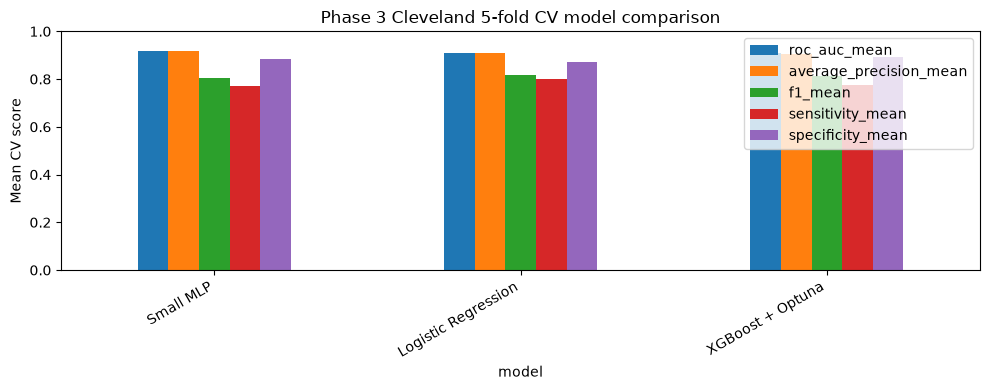

In [35]:
plot_cols = ["roc_auc_mean", "average_precision_mean", "f1_mean", "sensitivity_mean", "specificity_mean"]
ax = cv_summary.set_index("model")[plot_cols].plot(kind="bar", figsize=(10, 4))
ax.set_title("Phase 3 Cleveland 5-fold CV model comparison")
ax.set_ylabel("Mean CV score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Final Phase 3 checklist

After running this notebook, verify:

- All three mandatory models were trained: Logistic Regression, XGBoost, and small MLP.
- All models use the same feature engineering + imputer + scaler pipeline.
- The preprocessing pipeline is fitted only inside Cleveland CV folds.
- XGBoost used at least 50 Optuna trials.
- Logistic Regression and MLP were also tuned, not left at defaults.
- Hungarian and Swiss were not used for model selection.
- CORAL is implemented as an isolated module so Phase 4 can compare domain adaptation on/off.
- Specificity is now numeric, not `NaN`.

For the future `src/03_modeling.py` runner, save the best estimators, Optuna study summary, CV metrics table, and feature names to `outputs/`.

In [36]:
print("Phase 3 completion checks")
print("LR optimized:", hasattr(lr_search, "best_params_"))
print("XGBoost Optuna trials:", len(study.trials))
print("MLP optimized:", hasattr(mlp_search, "best_params_"))
print("Engineered feature count:", len(feature_engineer.get_feature_names_out()))
print("Domain adaptation module available:", CORALAdapter is not None)
print("External splits loaded but not evaluated in Phase 3:", hungarian.shape, swiss.shape)
print("Specificity values:")
print(cv_summary[["model", "specificity_mean", "specificity_std"]])

Phase 3 completion checks
LR optimized: True
XGBoost Optuna trials: 50
MLP optimized: True
Engineered feature count: 19
Domain adaptation module available: True
External splits loaded but not evaluated in Phase 3: (294, 16) (123, 16)
Specificity values:
                 model  specificity_mean  specificity_std
0            Small MLP          0.884470         0.039691
1  Logistic Regression          0.872348         0.039576
2     XGBoost + Optuna          0.890530         0.023485
